# ARIMA Minimal – Air Passengers
Die kürzeste Strecke von Rohdaten zur 12-Monats-Prognose.

## 1 – Daten laden

In [2]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings('ignore')

passagiere = [
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432]

ts = pd.Series(passagiere,
               index=pd.date_range('1949-01', periods=144, freq='MS'),
               name='pax')
ts.tail()

1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Name: pax, dtype: int64

## 2 – Log-Transformation (Varianz stabilisieren)

In [3]:
ts_log = np.log(ts)

## 3 – Stationarität prüfen (ADF-Test)

In [4]:
from statsmodels.tsa.stattools import adfuller

stat, p, *_ = adfuller(ts_log, autolag='AIC')
print(f'Rohdaten (log):  ADF={stat:.3f}  p={p:.4f}  → {"stationär" if p<0.05 else "NICHT stationär"}')

Rohdaten (log):  ADF=-1.717  p=0.4224  → NICHT stationär


## 4 – Differenzierung (d=1)

In [5]:
ts_diff = ts_log.diff().dropna()

stat, p, *_ = adfuller(ts_diff, autolag='AIC')
print(f'Nach Diff(1):    ADF={stat:.3f}  p={p:.4f}  → {"stationär" if p<0.05 else "NICHT stationär"}')

Nach Diff(1):    ADF=-2.717  p=0.0711  → NICHT stationär


## 5 – ACF / PACF ablesen → p, q bestimmen

In [6]:
from statsmodels.tsa.stattools import acf, pacf

ts_sdiff = ts_diff.diff(12).dropna()
acf_vals  = acf(ts_sdiff, nlags=12)
pacf_vals = pacf(ts_sdiff, nlags=12, method='ywm')

print('Lag   ACF    PACF')
for i in range(13):
    print(f' {i:2d}  {acf_vals[i]:+.3f}  {pacf_vals[i]:+.3f}')

Lag   ACF    PACF
  0  +1.000  +1.000
  1  -0.341  -0.341
  2  +0.105  -0.013
  3  -0.202  -0.193
  4  +0.021  -0.125
  5  +0.056  +0.033
  6  +0.031  +0.035
  7  -0.056  -0.060
  8  -0.001  -0.020
  9  +0.176  +0.226
 10  -0.076  +0.043
 11  +0.064  +0.047
 12  -0.387  -0.339


## 6 – Modell schätzen (SARIMA)

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modell = SARIMAX(ts_log,
                 order=(1,1,1),
                 seasonal_order=(1,1,1,12)).fit(disp=False)

print(f'Ordnung:  SARIMA(1,1,1)(1,1,1)₁₂')
print(f'AIC = {modell.aic:.2f}')
print(f'BIC = {modell.bic:.2f}')

Ordnung:  SARIMA(1,1,1)(1,1,1)₁₂
AIC = -480.30
BIC = -465.93


## 7 – Residuen-Check (Ljung-Box)

In [8]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(modell.resid[13:], lags=[12,24], return_df=True)
for lag, row in lb.iterrows():
    ok = '✓' if row['lb_pvalue'] > 0.05 else '✗'
    print(f'Lag {lag:2d}:  p={row["lb_pvalue"]:.4f}  {ok}')

Lag 12:  p=0.8418  ✓
Lag 24:  p=0.5960  ✓


## 8 – Prognose (12 Monate)

In [9]:
fc = modell.get_forecast(12)
ergebnis = np.exp(fc.predicted_mean)
ci       = np.exp(fc.conf_int())

ergebnis.index = pd.date_range('1961-01', periods=12, freq='MS')
ci.index       = ergebnis.index

print(f'{"Monat":>10s}  {"Prognose":>8s}  {"95%-KI":>16s}')
for d, v, lo, hi in zip(ergebnis.index, ergebnis, ci.iloc[:,0], ci.iloc[:,1]):
    print(f'{d.strftime("%b %Y"):>10s}  {v:>8.0f}  [{lo:>6.0f} – {hi:>6.0f}]')

     Monat  Prognose            95%-KI
  Jan 1961       451  [   420 –    485]
  Feb 1961       427  [   392 –    464]
  Mar 1961       482  [   440 –    529]
  Apr 1961       493  [   446 –    545]
  May 1961       511  [   459 –    568]
  Jun 1961       585  [   523 –    655]
  Jul 1961       673  [   597 –    758]
  Aug 1961       672  [   593 –    761]
  Sep 1961       561  [   492 –    639]
  Oct 1961       499  [   436 –    571]
  Nov 1961       432  [   375 –    497]
  Dec 1961       480  [   415 –    555]


## 9 – Prognose-Plot

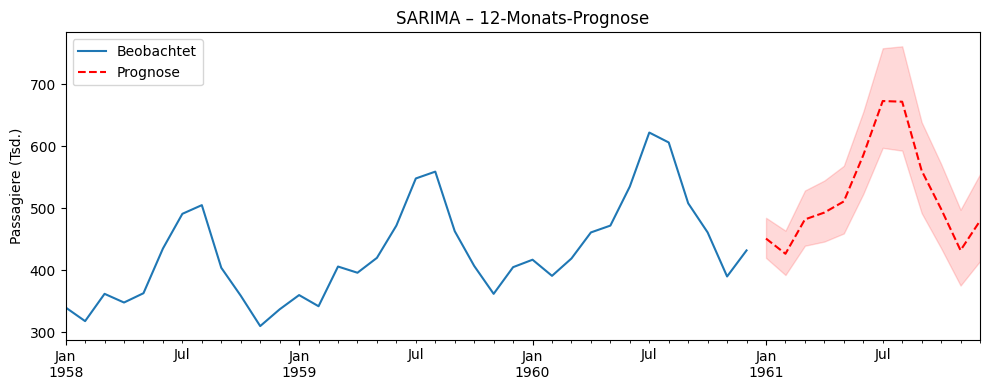

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,4))
ts[-36:].plot(ax=ax, label='Beobachtet')
ergebnis.plot(ax=ax, style='--r', label='Prognose')
ax.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], alpha=.15, color='r')
ax.set_ylabel('Passagiere (Tsd.)')
ax.legend()
ax.set_title('SARIMA – 12-Monats-Prognose')
plt.tight_layout()
plt.show()